# Exploring Advanced Data Visualization with Matplotlib and Seaborn
In this activity, we will explore how to create advanced and informative data visualizations using Python’s powerful visualization libraries, Matplotlib and Seaborn. Through hands-on exercises, you will analyze real datasets and build charts such as violin plots, heatmaps, pair plots, and multi-plot dashboards. The goal is to learn how to customize visualizations and choose the most effective chart types to clearly communicate patterns and relationships in data.

### Import  Packages

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

sns.set_theme(style="whitegrid")

In [30]:
# Restaurant Tips data
tips = sns.load_dataset("tips")

#penguins data
penguins = sns.load_dataset("penguins")

In [3]:
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [4]:
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


### Violin PLot 
(Boxplot + Density )
* Bosplot only shows the 5 number summary
* nothing about how data distributes inside the box
* Violin plot helps with that
* width is how much data is at that value

C:\Users\black\AppData\Local\Temp\ipykernel_14708\1411206851.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


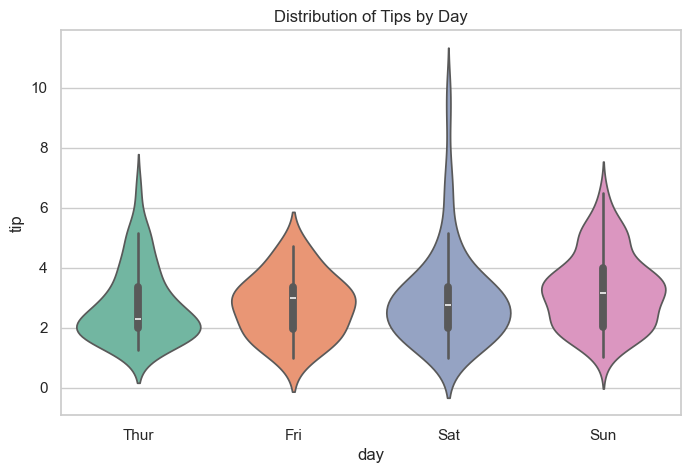

In [31]:
plt.figure(figsize=(8,5))

sns.violinplot(
    data=tips,
    x="day",
    y="tip",
    palette="Set2"
)

plt.title("Distribution of Tips by Day")
plt.show()

### 2. Pair Plot (Multivariable Exploration)
Some question you can get answer from penguins data:

Which species clusters together?

Which features separate species best?

* if you don't want all the variables, you can select which columns you *Do* want in the parentheses i,e, penguins['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm'] (I think this syntax is correct)
* useful for seeing which pairs are best for selecting for future modeling

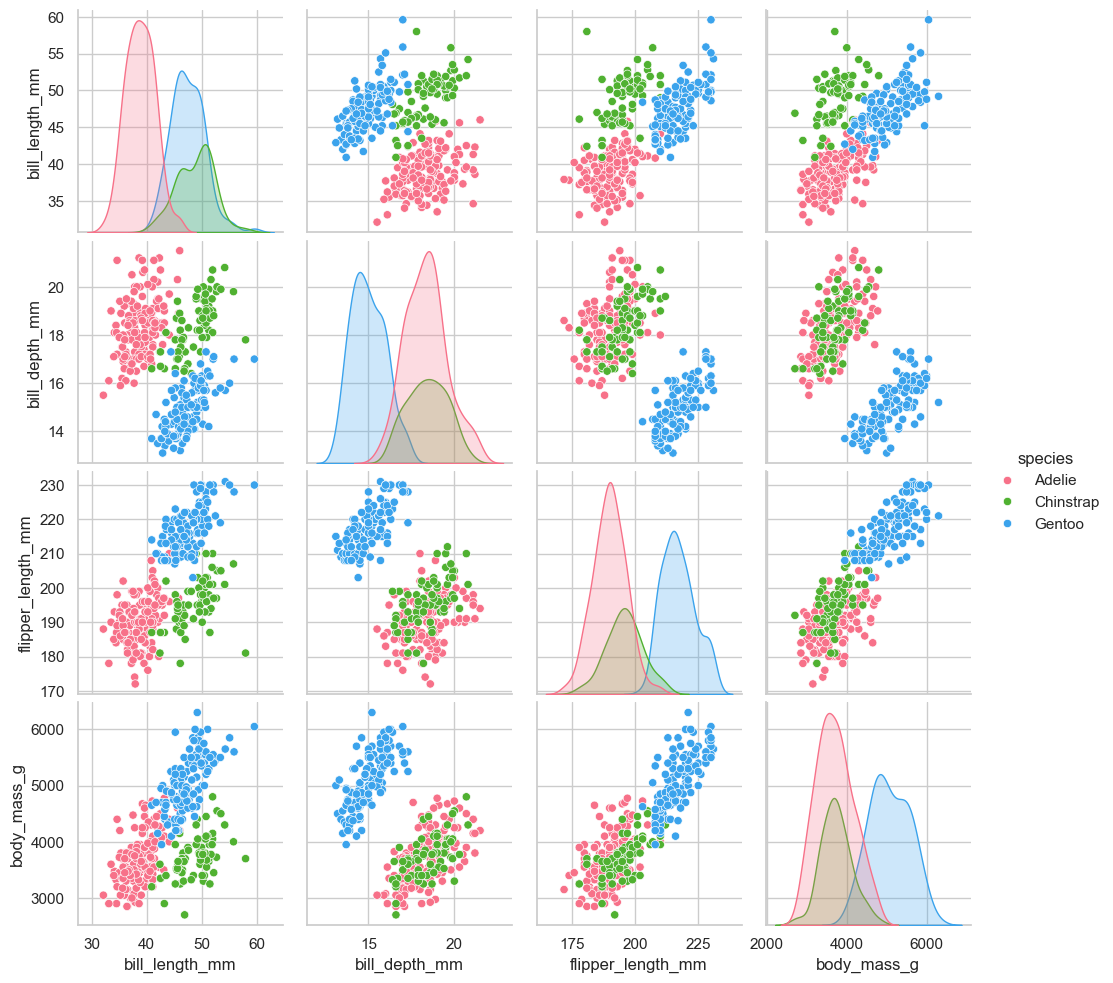

In [9]:
sns.pairplot(
    penguins,
    hue="species",
    palette="husl" # this is NOT a typo, surprisngly 
) # needs to be on the next line, apparently
    # shows scatter plots for each two variable pair. Shows histogram for where the square where the same variables meet.


### 3. Heatmap Correlation Matrix (MultiVariable)
- Which variables are strongly correlated?

- Which ones are unrelated?

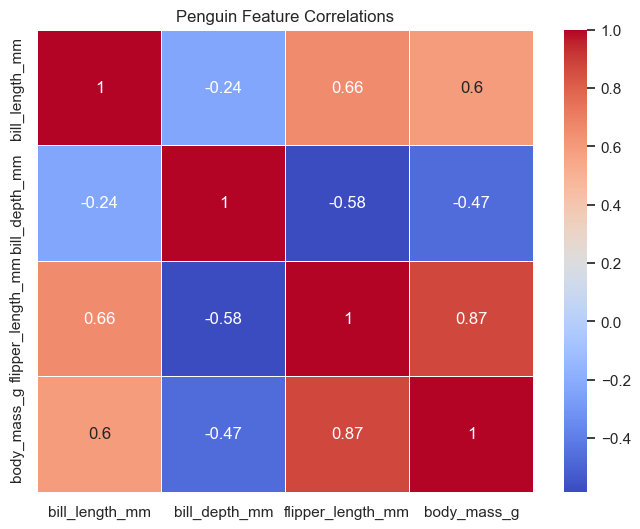

In [10]:
corr = penguins.corr(numeric_only=True)

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True, #annotations true gives the numerical value in the heatmap square
    cmap="coolwarm",
    linewidths=0.5 # the line between squares
)

plt.title("Penguin Feature Correlations")
plt.show()

### 4. Joint Plot (Relationship + Distribution)
if you don't defind kind, it will be a scatter plot with a histogram on the top and side of the plot

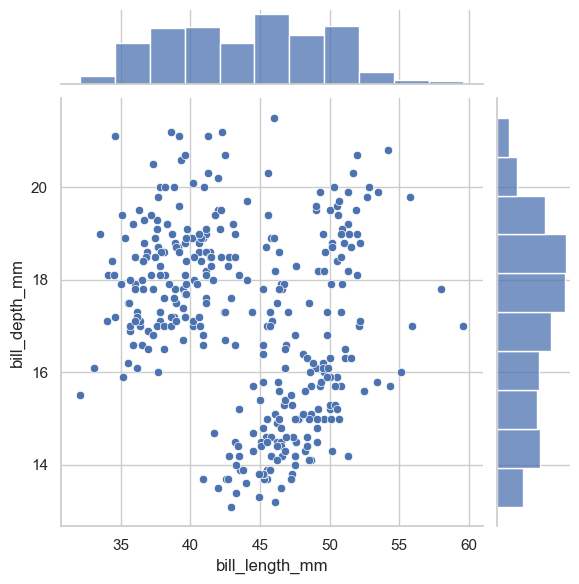

In [16]:
sns.jointplot(
    data=penguins,
    x="bill_length_mm",
    y="bill_depth_mm",
    #kind="kde" #kernel density estimation; looks like a fried egg???? smaller circles show higher desnity, with density curve on top and right side
    #kind= "hex" # darker hexes show darker density of values; again histogram on sides
)

### 5. Multi-Plot Dashboard
* multiple charts that can be different!

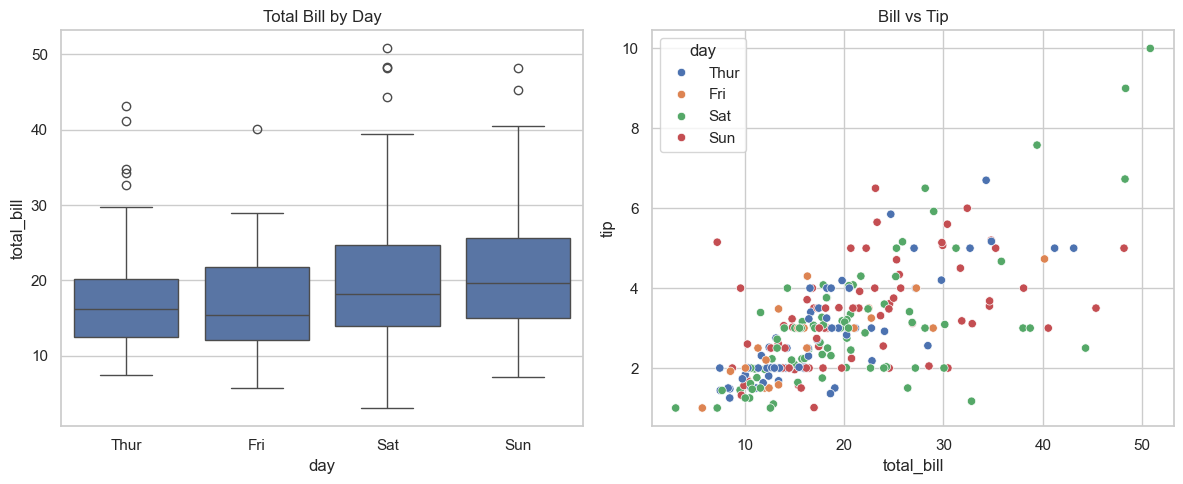

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12,5)) # 1 row, 2 columns, figsize
 
sns.boxplot(
    data=tips,
    x="day",
    y="total_bill",
    ax=axes[0] #axes 0 means the first subplot index number rules
)

sns.scatterplot(
    data=tips,
    x="total_bill",
    y="tip",
    hue="day",
    ax=axes[1] # axes 1 is the second plot 
)

axes[0].set_title("Total Bill by Day")
axes[1].set_title("Bill vs Tip")

plt.tight_layout()
plt.show()

### 6. Create Your own Visualization Answering the Follwoing Questions 
- Does party size affect tip size?

- Do penguin species differ in body mass?

- What variables correlate with bill length?

### Party size and Tip Size

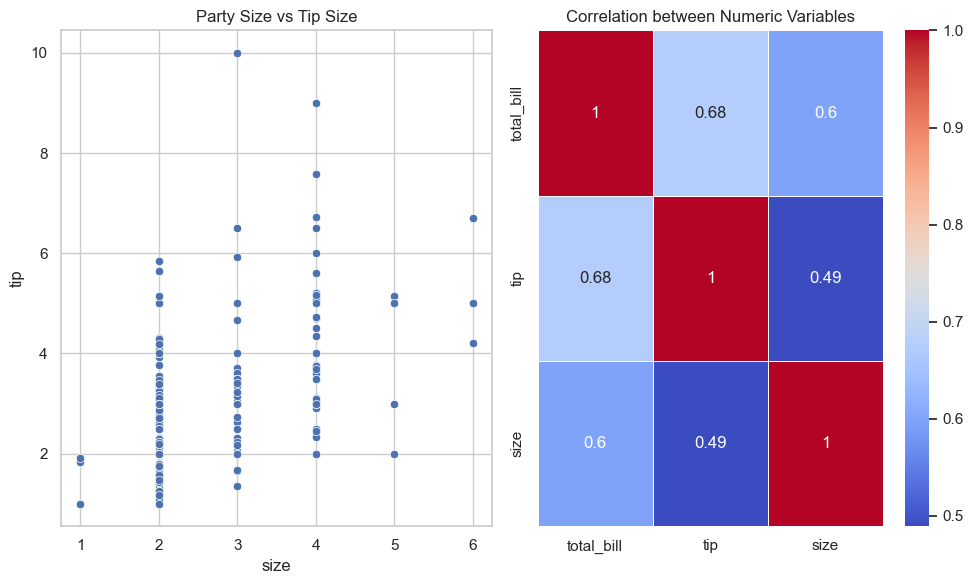

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(10, 6))

sns.scatterplot(
    data = tips,
    x = "size",
    y = 'tip',
    ax = axes[0]
)

corr = tips.corr(numeric_only=True)
sns.heatmap(
    corr, 
    annot = True,
    cmap = "coolwarm",
    linewidths= 0.7)

axes[0].set_title('Party Size vs Tip Size')
axes[1].set_title('Correlation between Numeric Variables')
plt.tight_layout()
plt.show()


Tip amounts start higher when there are more people in the party. While there is some correlation between party size and tip amount, it is not the strongest. 

### Do penguin species differ in body mass?

C:\Users\black\AppData\Local\Temp\ipykernel_14708\3402625686.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


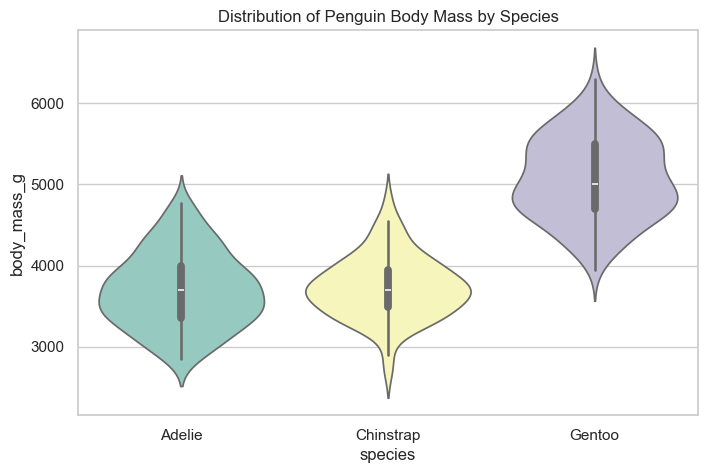

In [33]:
plt.figure(figsize=(8,5))

sns.violinplot(
    data=penguins,
    x="species",
    y="body_mass_g",
    palette="Set3"
)

plt.title("Distribution of Penguin Body Mass by Species")
plt.show()

Yes, penguin speices differ in body mass. While the Adelie and Chinstrap penguins are the same mass, with most around 3500-3700g, and *some* reach 5000 grams, the Gentoo species outweights them, with the majority weighting between about 4700 and 5500 grams. 

### What variables correlate with bill length?

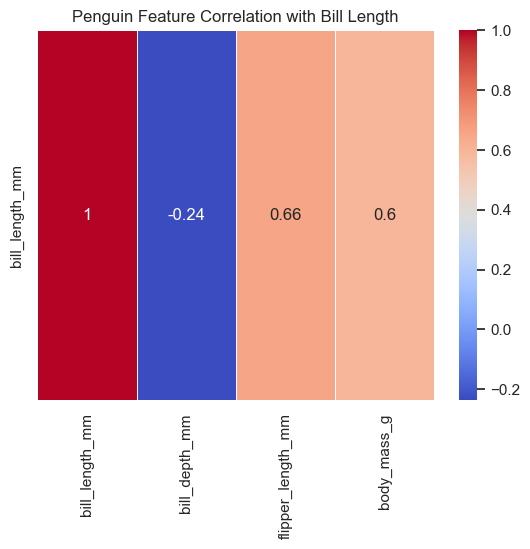

In [71]:
corr = penguins.corr(numeric_only=True)
corr

bill_length_corr = corr.filter(items = ['bill_length_mm'], axis = 0)
bill_length_corr

sns.heatmap(
    bill_length_corr,
    annot=True, 
    cmap="coolwarm",
    linewidths=0.7
)
plt.title("Penguin Feature Correlation with Bill Length")
plt.show()

### Bonus Tip: Using axes.flat to Loop Through Subplots

Flipper length and body mass have the strongest correlation with bill length. 

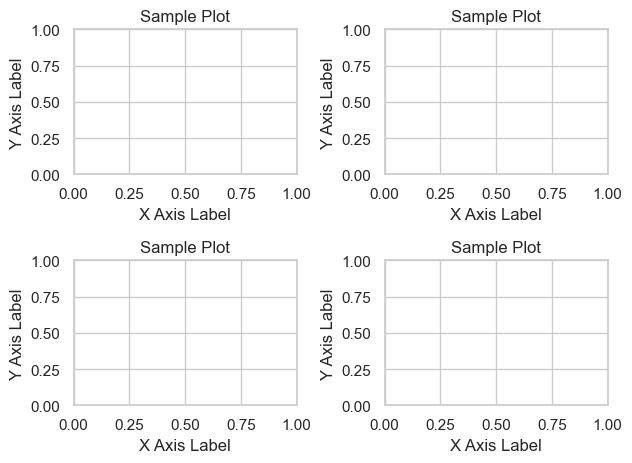

In [18]:
fig, axes = plt.subplots(2,2)

for ax in axes.flat:
    ax.set_title("Sample Plot")
    ax.set_xlabel("X Axis Label")
    ax.set_ylabel("Y Axis Label")

plt.tight_layout()

plt.show()